# 한국어 독성 댓글 탐지 모델 학습 및 평가
### KOLD 데이터셋 + 한국어 ELECTRA 기반 이진 분류

이 노트북은 다음 목표를 기준으로 작성되었습니다.

- **데이터셋 요약과 라벨링 방식**을 명확히 기록
- **학습 전략과 기본 모델**을 구조적으로 정리
- **실제값 vs 예측값(Actual vs Predicted)**, **Confusion Matrix**, **ROC Curve**, **학습 곡선**을 산출
- **Streamlit Cloud 서비스용 아티팩트**를 함께 저장

최종 산출물은 아래 폴더에 저장됩니다.

- `artifacts/model/` : 학습된 모델과 토크나이저
- `artifacts/images/` : PPT/보고서/Streamlit에 재사용할 그래프
- `artifacts/data/` : 예측 결과 CSV, 오분류 사례, 분류 리포트, 메타데이터

## 1. 프로젝트 개요 및 목표

### 프로젝트 목표
한국어 댓글을 **정상(normal)** 과 **독성(toxic)** 으로 분류하는 딥러닝 기반 텍스트 분류 모델을 구축한다.

### 해결하려는 문제
- 실시간 방송, 커뮤니티, 채팅 환경에서 공격적·비하적 댓글이 빠르게 확산될 수 있음
- 단순 욕설 사전 매칭만으로는 **암시적 공격 표현**을 충분히 다루기 어려움
- 한국어 댓글 도메인에 맞는 사전학습 언어모델을 활용해 자동 탐지 성능을 확보하고자 함

### 최종 결과물
- 한국어 독성 댓글 이진 분류 모델
- Streamlit Cloud 시연용 서비스 코드
- 성능 평가 시각화 결과물

## 2. 데이터셋 설명 및 라벨링 방식

### 사용 데이터셋
- **KOLD (Korean Offensive Language Dataset)**  
- Hugging Face `load_dataset("nayohan/KOLD")` 로 로드

### 입력 컬럼
- `comment` : 실제 댓글 본문

### 라벨링 방식
- `OFF == True` → `toxic`
- `OFF == False` → `normal`

### 분할 전략
- 원본 train split을 사용한 뒤
- **Stratified 8:1:1 분할**로 `train / validation / test` 구성

### 학습 전략 요약
- 한국어 댓글 도메인에 적합한 **ELECTRA small 계열 모델** 사용
- 길이 제한과 epoch 수를 조절하여 **CPU/노트북 환경에서도 재현 가능**하게 구성
- 클래스 불균형 보완을 위해 **class weight 기반 손실 함수** 적용

## 3. 기본 설정 및 라이브러리
> 처음 실행하는 환경이라면 아래 주석의 pip 명령을 먼저 실행하세요.
>
> `pip install datasets transformers torch scikit-learn pandas matplotlib streamlit accelerate`

In [1]:
# !pip install datasets transformers torch scikit-learn pandas matplotlib streamlit accelerate

from __future__ import annotations

import inspect
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import DatasetDict, load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.options.display.max_colwidth = 200

d:\git\project_week3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. 하이퍼파라미터 및 저장 경로
- 기본 모델은 **`beomi/KcELECTRA-small-v2022`**
- 필요하면 `monologg/koelectra-small-v3-discriminator` 로 바꿔도 됨

In [2]:
SEED = 42
MODEL_NAME = "beomi/KcELECTRA-small-v2022"
MAX_LENGTH = 64
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
LEARNING_RATE = 2e-5
NUM_EPOCHS = 1
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

ARTIFACT_ROOT = Path("artifacts")
MODEL_DIR = ARTIFACT_ROOT / "model"
IMAGE_DIR = ARTIFACT_ROOT / "images"
DATA_DIR = ARTIFACT_ROOT / "data"

for directory in [MODEL_DIR, IMAGE_DIR, DATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0: "normal", 1: "toxic"}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEVICE = {DEVICE}")

DEVICE = cpu


## 5. 데이터 로드 및 이진 라벨 변환

In [3]:
def prepare_kold_dataset() -> tuple[DatasetDict, pd.DataFrame]:
    raw = load_dataset("nayohan/KOLD")
    base = raw["train"]

    def map_fn(example):
        return {
            "text": example["comment"],
            "label": int(bool(example["OFF"])),
            "title": example.get("title", ""),
            "source": example.get("source", ""),
        }

    mapped = base.map(map_fn)
    keep_cols = ["text", "label", "title", "source"]
    mapped = mapped.remove_columns([c for c in mapped.column_names if c not in keep_cols])

    overview_df = mapped.to_pandas().copy()
    mapped = mapped.class_encode_column("label")

    split_1 = mapped.train_test_split(
        test_size=0.2,
        seed=SEED,
        stratify_by_column="label",
    )
    split_2 = split_1["test"].train_test_split(
        test_size=0.5,
        seed=SEED,
        stratify_by_column="label",
    )

    dataset = DatasetDict(
        {
            "train": split_1["train"],
            "validation": split_2["train"],
            "test": split_2["test"],
        }
    )
    return dataset, overview_df


dataset, overview_df = prepare_kold_dataset()
print(dataset)
overview_df.head()

DatasetDict({
    train: Dataset({
        features: ['source', 'title', 'text', 'label'],
        num_rows: 32343
    })
    validation: Dataset({
        features: ['source', 'title', 'text', 'label'],
        num_rows: 4043
    })
    test: Dataset({
        features: ['source', 'title', 'text', 'label'],
        num_rows: 4043
    })
})


,source,title,text,label
0,naver_news,페미니즘이 범죄가 되는 나라 [삶과 문화],남녀평등 주장할 거면 여성징병제에도 동의하라고ㅋㅋㅋ 그리고 내 말에 그냥 시비만 걸지 말고 혜택은 다 쳐받으면서 왜 차별받는다고 말하는지 말해보라고ㅋㅋㅋ,1
1,naver_news,[젠더의학①] 여성은 ‘몸집 작은 남성’이 아니다,의학에도 젠더 사상이 붙네 ㄷㄷ;,1
2,naver_news,“책 생명 늘려야죠”… 문학 속 ‘성차별’ 패치 떼는 출판계,"루브르 박물관에 있는 모나리자 머리도 단발로 수정하고,미국에 있는 자유의 여신상도 콘크리트 부어서 가슴부분 가리자",1
3,naver_news,이루다로 촉발된 젠더 논쟁... 개인정보 유출이란 본질 외면,진짜 어이가 없네 딥페이크 만든 사람들도 처벌하고 알페스 만든 사람들도 처벌하라니깐?? 왜 알페스 얘기 꺼내면 딥페이크 얘기로 돌리려고 하는지 모르겠네 둘다 처벌 받음 되지 왜 쫄리나..?,1
4,naver_news,"GS25, 브레이브걸스 포스터 또 젠더 이슈 논란",브레이브걸스=페미아이돌,1


## 6. 데이터셋 요약

In [4]:
summary = {
    "total_samples": len(overview_df),
    "train_samples": len(dataset["train"]),
    "validation_samples": len(dataset["validation"]),
    "test_samples": len(dataset["test"]),
    "label_distribution": overview_df["label"].value_counts().sort_index().to_dict(),
}

summary["label_distribution_named"] = {
    LABEL_MAP[int(k)]: int(v) for k, v in summary["label_distribution"].items()
}

summary_df = pd.DataFrame(
    {
        "구분": ["전체", "학습", "검증", "테스트"],
        "샘플 수": [
            summary["total_samples"],
            summary["train_samples"],
            summary["validation_samples"],
            summary["test_samples"],
        ],
    }
)

display(summary_df)
display(
    overview_df[["text", "label", "source"]]
    .assign(label_name=lambda x: x["label"].map(LABEL_MAP))
    .sample(5, random_state=SEED)
    .reset_index(drop=True)
)

with open(DATA_DIR / "dataset_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

,구분,샘플 수
0,전체,40429
1,학습,32343
2,검증,4043
3,테스트,4043


,text,label,source,label_name
0,돈 있으면 징역살지않아도 되는 법.합의하면 징역도 무죄로 바꿔주는 법..이게 옳을까요?,0,naver_news,normal
1,미군 군사무기장비 놓고온건 잘못된거쥬 .,0,youtube,normal
2,고요하고...편안하고...맑아집니다~~♡ 이 느낌 그대로 지금 바로 천국의 삶 누리겠습니다~~♡,0,youtube,normal
3,"Amen, thank you pastor",0,youtube,normal
4,동성애자들은 돌멩이로 머리를 내려쳐야 한다,1,naver_news,toxic


## 7. 라벨 분포 시각화

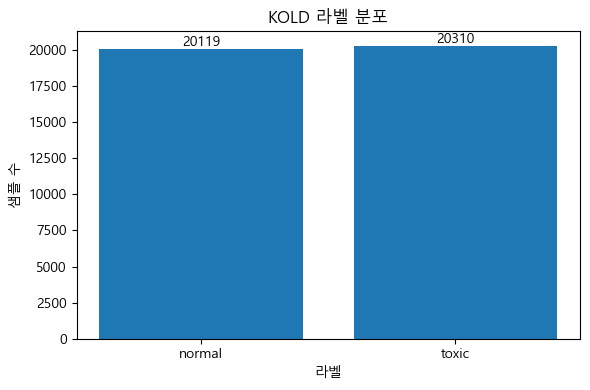

In [5]:
label_counts = overview_df["label"].value_counts().sort_index()
label_names = [LABEL_MAP[idx] for idx in label_counts.index]

plt.figure(figsize=(6, 4))
bars = plt.bar(label_names, label_counts.values)
plt.title("KOLD 라벨 분포")
plt.xlabel("라벨")
plt.ylabel("샘플 수")
for bar, value in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

label_distribution_df = pd.DataFrame({"label": label_names, "count": label_counts.values})
label_distribution_df.to_csv(DATA_DIR / "label_distribution.csv", index=False, encoding="utf-8-sig")

## 8. 토크나이저 및 토크나이징

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized

DatasetDict({
    train: Dataset({
        features: ['source', 'title', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 32343
    })
    validation: Dataset({
        features: ['source', 'title', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4043
    })
    test: Dataset({
        features: ['source', 'title', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4043
    })
})

## 9. 학습 전략 및 기본 모델

### 기본 모델
- `beomi/KcELECTRA-small-v2022`

### 선택 이유
- 한국어 댓글/구어체 환경에 비교적 적합한 ELECTRA 계열
- base보다 작아서 CPU 환경에서도 실험 가능성이 높음
- Streamlit 서비스 배포 시 로딩 부담을 다소 줄일 수 있음

### 학습 전략
- Stratified split
- Weighted Cross Entropy
- Early Stopping
- Best checkpoint 기준 저장

In [7]:
train_labels = np.array(dataset["train"]["label"])
classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels,
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([1.0048, 0.9953])

In [8]:
def build_training_args() -> TrainingArguments:
    signature = inspect.signature(TrainingArguments.__init__)
    kwargs = {
        "output_dir": str(ARTIFACT_ROOT / "checkpoints"),
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "num_train_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "save_total_limit": 1,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "logging_steps": 50,
        "report_to": "none",
        "dataloader_num_workers": 0,
    }

    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    if "save_strategy" in signature.parameters:
        kwargs["save_strategy"] = "epoch"

    if "logging_strategy" in signature.parameters:
        kwargs["logging_strategy"] = "steps"

    if "use_cpu" in signature.parameters and not torch.cuda.is_available():
        kwargs["use_cpu"] = True

    if "save_safetensors" in signature.parameters:
        kwargs["save_safetensors"] = True

    return TrainingArguments(**kwargs)


def softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax_np(logits)
    preds = np.argmax(probs, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(auc) if not math.isnan(auc) else None,
    }


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights: torch.Tensor | None = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is None:
            loss = outputs.get("loss")
        else:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

## 10. 모델 학습

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=LABEL_MAP,
    label2id=INV_LABEL_MAP,
)

training_args = build_training_args()

trainer_kwargs = {
    "model": model,
    "args": training_args,
    "train_dataset": tokenized["train"],
    "eval_dataset": tokenized["validation"],
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
    "callbacks": [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    "class_weights": class_weights,
}

trainer_signature = inspect.signature(Trainer.__init__)
if "processing_class" in trainer_signature.parameters:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

train_result = trainer.train()
train_result

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18592.35it/s]
ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-small-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MI

Epoch,Training Loss,Validation Loss


## 11. 검증/테스트 성능 평가

In [ ]:
val_metrics = trainer.evaluate(tokenized["validation"])
test_metrics = trainer.evaluate(tokenized["test"])

metrics_bundle = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "validation_metrics": val_metrics,
    "test_metrics": test_metrics,
}

with open(DATA_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_bundle, f, ensure_ascii=False, indent=2)

pd.DataFrame(
    [
        {"split": "validation", **val_metrics},
        {"split": "test", **test_metrics},
    ]
)

RuntimeError: on_train_begin must be called before on_evaluate

## 12. 테스트셋 예측 결과 생성

In [ ]:
pred_output = trainer.predict(tokenized["test"])
test_logits = pred_output.predictions
test_probs = softmax_np(test_logits)
test_preds = np.argmax(test_probs, axis=1)
test_labels = np.array(dataset["test"]["label"])
test_texts = list(dataset["test"]["text"])

pred_df = pd.DataFrame(
    {
        "text": test_texts,
        "actual": test_labels,
        "predicted": test_preds,
        "actual_label": [LABEL_MAP[int(x)] for x in test_labels],
        "predicted_label": [LABEL_MAP[int(x)] for x in test_preds],
        "prob_normal": test_probs[:, 0],
        "prob_toxic": test_probs[:, 1],
        "correct": test_labels == test_preds,
    }
)

pred_df.to_csv(DATA_DIR / "predictions_test.csv", index=False, encoding="utf-8-sig")
pred_df.head()

## 13. 분류 리포트, 오분류 사례 저장

In [ ]:
report_dict = classification_report(
    test_labels,
    test_preds,
    target_names=["normal", "toxic"],
    output_dict=True,
    zero_division=0,
)

with open(DATA_DIR / "classification_report.json", "w", encoding="utf-8") as f:
    json.dump(report_dict, f, ensure_ascii=False, indent=2)

false_positive_df = pred_df[(pred_df["actual"] == 0) & (pred_df["predicted"] == 1)].copy()
false_negative_df = pred_df[(pred_df["actual"] == 1) & (pred_df["predicted"] == 0)].copy()

false_positive_df.to_csv(DATA_DIR / "false_positives.csv", index=False, encoding="utf-8-sig")
false_negative_df.to_csv(DATA_DIR / "false_negatives.csv", index=False, encoding="utf-8-sig")

display(pd.DataFrame(report_dict).transpose())
display(false_positive_df.head(5))
display(false_negative_df.head(5))

## 14. Confusion Matrix 시각화

In [ ]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1], labels=["normal", "toxic"])
ax.set_yticks([0, 1], labels=["normal", "toxic"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. ROC Curve 시각화

In [ ]:
fpr, tpr, thresholds = roc_curve(test_labels, test_probs[:, 1])
roc_auc = roc_auc_score(test_labels, test_probs[:, 1])

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Actual vs Predicted 시각화
> PPT/보고서에서 바로 사용할 수 있도록 `plt.show()` 기반 그래프를 생성합니다.

In [ ]:
N_SAMPLES_TO_PLOT = min(120, len(pred_df))
plot_df = pred_df.head(N_SAMPLES_TO_PLOT).copy()

plt.figure(figsize=(12, 4))
plt.plot(plot_df.index, plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df.index, plot_df["predicted"], label="Predicted", linestyle="--", linewidth=2)
plt.title(f"Actual vs Predicted (Top {N_SAMPLES_TO_PLOT} Test Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Label (0=normal, 1=toxic)")
plt.yticks([0, 1], ["normal", "toxic"])
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. 학습 곡선 시각화

In [ ]:
log_history = trainer.state.log_history
history_df = pd.DataFrame(log_history)
history_df.to_csv(DATA_DIR / "training_history.csv", index=False, encoding="utf-8-sig")

plot_history = history_df.copy()

plt.figure(figsize=(8, 4))
if "loss" in plot_history.columns:
    train_loss_df = plot_history.dropna(subset=["loss"])
    if not train_loss_df.empty:
        plt.plot(train_loss_df["step"], train_loss_df["loss"], label="train_loss")
if "eval_loss" in plot_history.columns:
    eval_loss_df = plot_history.dropna(subset=["eval_loss"])
    if not eval_loss_df.empty:
        plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], label="eval_loss")

plt.title("Training History")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 18. 테스트셋 확률 분포 시각화

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(pred_df["prob_toxic"], bins=20)
plt.title("Predicted Toxic Probability Distribution")
plt.xlabel("prob_toxic")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 19. 모델 및 토크나이저 저장

In [ ]:
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

artifact_manifest = {
    "model_dir": str(MODEL_DIR),
    "image_dir": str(IMAGE_DIR),
    "data_dir": str(DATA_DIR),
    "saved_files": sorted(
        [str(path.relative_to(ARTIFACT_ROOT)) for path in ARTIFACT_ROOT.rglob("*") if path.is_file()]
    ),
}

with open(DATA_DIR / "artifact_manifest.json", "w", encoding="utf-8") as f:
    json.dump(artifact_manifest, f, ensure_ascii=False, indent=2)

artifact_manifest

## 20. Streamlit 서비스 연동 체크
아래 파일들이 생성되었으면 Streamlit 서비스에서 바로 재사용할 수 있습니다.

- `artifacts/model/`
- `artifacts/data/metrics.json`
- `artifacts/data/classification_report.json`
- `artifacts/data/predictions_test.csv`
- `artifacts/images/confusion_matrix.png`
- `artifacts/images/roc_curve.png`
- `artifacts/images/actual_vs_predicted.png`
- `artifacts/images/training_history.png`

In [ ]:
for path in sorted(ARTIFACT_ROOT.rglob("*")):
    print(path)